# Sigma-Delta Modulator — Simulação High-Level
### Lab 2 | Conversores de Sinal | FCT/UNL (Nuno Paulino, 2026)

**Modulador de 2ª ordem, 1-bit**  
$$\text{STF}(z) = z^{-2} \qquad \text{NTF}(z) = (1 - z^{-1})^2$$

Parâmetros: $\beta=1,\ k_1=k_2=1,\ b_1=1,\ b_2=2$

---


## Imports e Parâmetros Globais

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import blackmanharris as _bh_scipy
import warnings
warnings.filterwarnings("ignore")

# ── Parâmetros globais ────────────────────────────────────────────────────
B    = 20e3           # Largura de banda [Hz]
OSR  = 115.8          # Oversampling ratio (calculado na alínea c)
Fs   = 2 * B * OSR    # Frequência de amostragem [Hz]
Vr   = 1     # Referência do quantizador 
b1   = 1.0
b2   = 2.0
Delta = 2 * Vr        # Passo do quantizador 1-bit

print(f"B   = {B/1e3:.1f} kHz")
print(f"OSR = {OSR}")
print(f"Fs  = {Fs/1e3:.2f} kHz  ({Fs/1e6:.4f} MHz)")
print(f"Vr  = {Vr:.4f} V  (= √2,  1 Vrms de pico)")
print(f"Δ   = {Delta:.4f} V")


B   = 20.0 kHz
OSR = 115.8
Fs  = 4632.00 kHz  (4.6320 MHz)
Vr  = 1.0000 V  (= √2,  1 Vrms de pico)
Δ   = 2.0000 V


---
## Alínea a) — Funções de Transferência: STF(z) e NTF(z)

Usando o modelo linear do quantizador (ganho = 1), o diagrama de Fig.2 dá:

$$\text{STF}(z) = z^{-2}$$

$$\text{NTF}(z) = (1 - z^{-1})^2 = 1 - 2z^{-1} + z^{-2}$$

O NTF tem dois zeros em $z=1$ (DC) — comportamento passa-alto de 2ª ordem que suprime o ruído de quantização na banda de sinal.


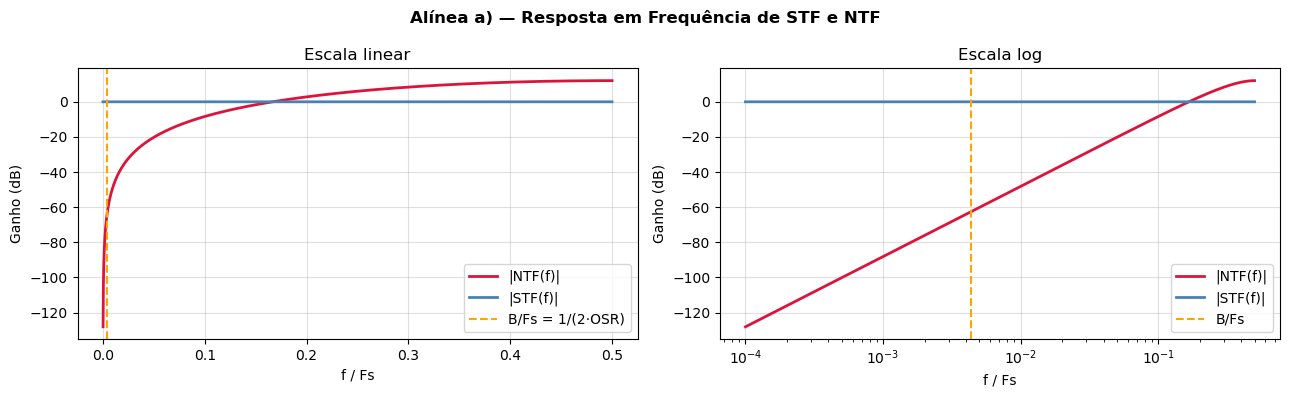

In [221]:
# Resposta em frequência do NTF e STF
f_norm = np.linspace(0, 0.5, 5000)   # f/Fs
z = np.exp(1j * 2 * np.pi * f_norm)

NTF = (1 - z**(-1))**2
STF = z**(-2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Alínea a) — Resposta em Frequência de STF e NTF", fontweight='bold')

axes[0].plot(f_norm, 20*np.log10(np.abs(NTF)), color='crimson',   lw=2, label='|NTF(f)|')
axes[0].plot(f_norm, 20*np.log10(np.abs(STF)), color='steelblue', lw=2, label='|STF(f)|')
axes[0].axvline(1/(2*OSR), color='orange', ls='--', label=f'B/Fs = 1/(2·OSR)')
axes[0].set_xlabel("f / Fs"); axes[0].set_ylabel("Ganho (dB)")
axes[0].set_title("Escala linear"); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].semilogx(f_norm[1:], 20*np.log10(np.abs(NTF[1:]) + 1e-15), color='crimson',   lw=2, label='|NTF(f)|')
axes[1].semilogx(f_norm[1:], 20*np.log10(np.abs(STF[1:]) + 1e-15), color='steelblue', lw=2, label='|STF(f)|')
axes[1].axvline(1/(2*OSR), color='orange', ls='--', label=f'B/Fs')
axes[1].set_xlabel("f / Fs"); axes[1].set_ylabel("Ganho (dB)")
axes[1].set_title("Escala log"); axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


---
## Alínea b) — Potência do Ruído de Quantização após LPF Ideal

Para NTF de 2ª ordem, a potência de ruído in-band é:

$$P_q = \frac{\Delta^2}{12} \cdot \frac{\pi^4}{5 \cdot \text{OSR}^5}$$

onde $\Delta = 2V_r$ é o passo do quantizador 1-bit.


In [222]:
P_q = (Delta**2 / 12) * (np.pi**4 / 5) / OSR**5

print("Potência do ruído de quantização in-band:")
print(f"  Δ   = 2·Vr = {Delta:.4f} V")
print(f"  P_q = (Δ²/12)·(π⁴/5)/OSR⁵")
print(f"  P_q = {P_q:.4e} V²   ({10*np.log10(P_q):.1f} dBV²)")


Potência do ruído de quantização in-band:
  Δ   = 2·Vr = 2.0000 V
  P_q = (Δ²/12)·(π⁴/5)/OSR⁵
  P_q = 3.1186e-10 V²   (-95.1 dBV²)


---
## Alínea c) — OSR Mínimo para SNR > 80 dB

O enunciado especifica:
- Amplitude de entrada: $v_{in} = V_r/2$ (amplitude de pico)  →  $P_s = (V_r/2)^2 / 2$
- Ruído térmico = $3 \times P_q$  →  ruído total = $4 \times P_q$
- Condição: $\text{SNR} = P_s / (4 P_q) > 10^{80/10}$

Substituindo a expressão de $P_q$:

$$\text{OSR} > \left( \frac{\Delta^2}{12} \cdot \frac{\pi^4}{5} \cdot \frac{4 \cdot \text{SNR}_{\text{target}}}{P_s} \right)^{1/5}$$


In [223]:
A_in   = Vr / 2
P_s    = A_in**2 / 2          # Potência RMS da sinusoide
SNR_target_dB  = 80
SNR_target_lin = 10**(SNR_target_dB / 10)

# Resolver OSR^5 > ...
OSR_min = ((Delta**2/12) * (np.pi**4/5) * 4 * SNR_target_lin / P_s) ** (1/5)

print(f"Amplitude de entrada  = Vr/2 = {A_in:.4f} V")
print(f"P_s                   = {P_s:.4f} V²")
print(f"SNR alvo              = {SNR_target_dB} dB")
print(f"OSR mínimo (exacto)   = {OSR_min:.2f}")
print(f"OSR escolhido         = {OSR}  (valor exacto mínimo)")
print(f"Fs = 2·B·OSR          = {Fs/1e3:.2f} kHz")


Amplitude de entrada  = Vr/2 = 0.5000 V
P_s                   = 0.1250 V²
SNR alvo              = 80 dB
OSR mínimo (exacto)   = 115.75
OSR escolhido         = 115.8  (valor exacto mínimo)
Fs = 2·B·OSR          = 4632.00 kHz


---
## Funções Auxiliares: Simulador SDM e Cálculo de SNDR


In [224]:
def simulate_sdm(vin_signal, Vr=np.sqrt(2), beta1=1.0, beta2=1.0, b1=1.0, b2=2.0):
    """
    Simulador high-level do SDM de 2ª ordem (Fig.2).
    
    Equações de estado:
        dout[n]   = sign(x2[n-1])            ← quantizador usa estado anterior
        erro1[n]  = vin[n] - Vr·dout[n]
        x1[n+1]   = beta1·x1[n] + erro1[n]   ← integrador 1 (com leakage)
        erro2[n]  = x1[n+1] - b2·Vr·dout[n]
        x2[n+1]   = beta2·x2[n] + erro2[n]   ← integrador 2 (com leakage)
    
    Parâmetros:
        beta1, beta2 : pólo do integrador (1.0 = ideal, <1 = ganho finito)
    """
    N    = len(vin_signal)
    x1   = 1e-12
    x2   = 0.0
    dout = np.zeros(N)

    for n in range(N):
        d       = Vr if x2 >= 0 else -Vr
        dout[n] = d
        erro1   = vin_signal[n] - b1 * Vr * d
        x1_new  = beta1 * x1 + erro1
        erro2   = x1_new - b2 * Vr * d
        x2      = beta2 * x2 + erro2
        x1      = x1_new

    return dout


def blackmanharris(N):
    from scipy.signal.windows import blackmanharris as _bh
    return _bh(N)


def compute_sndr(dout, k_bin, np_total, OSR, win=None):
    """
    Calcula SNDR a partir do bitstream, usando indexação de bins compatível
    com o MATLAB (bin k_bin = frequência do sinal).
    
    k_bin    : índice do bin do sinal (inteiro, amostragem coerente)
    np_total : comprimento do FFT
    OSR      : para definir a largura de banda
    """
    if win is None:
        win = blackmanharris(np_total)
    X    = np.fft.fft(dout * win)
    pwr  = np.abs(X / np_total * 2)**2

    # Bins do sinal (±4 bins à volta do pico, como no MATLAB)
    sig_bins  = np.arange(k_bin - 4, k_bin + 5)
    # Bins in-band: 1 até np/(2·OSR)+1
    band_end  = int(np_total / (2 * OSR)) + 2
    band_bins = np.arange(1, band_end)

    P_sig   = np.sum(pwr[sig_bins])
    P_noise = np.sum(pwr[band_bins]) - P_sig
    sndr_dB = 10 * np.log10(P_sig / P_noise) if P_noise > 0 else np.inf
    return sndr_dB, pwr


# ── Parâmetros de simulação ────────────────────────────────────────────────
np_sim = 90000          # nº de pontos base
k_idx  = 21             # índice do bin de frequência
fin_norm = k_idx * (Fs / np_sim) / Fs   # fin normalizado
# Ajustar np para garantir número inteiro de ciclos 
np_sim = round(round(np_sim * fin_norm) / fin_norm)
k_bin  = round(np_sim * fin_norm)       # bin do sinal após ajuste
fin    = k_bin * Fs / np_sim            # frequência exacta em Hz

# Ruído térmico adequado: 3 × P_q
noise_sigma = np.sqrt(3 * P_q)

t = np.arange(np_sim) / Fs

print(f"np_sim  = {np_sim} amostras")
print(f"fin     = {fin:.2f} Hz  (bin k={k_bin})")
print(f"Ruído térmico σ = {noise_sigma:.4e} V  (3×P_q = {3*P_q:.4e} V²)")


np_sim  = 90000 amostras
fin     = 1080.80 Hz  (bin k=21)
Ruído térmico σ = 3.0587e-05 V  (3×P_q = 9.3559e-10 V²)


---
## Alínea d) — Modelo High-Level: Gerar dout

Simulação com $v_{in} = (V_r/2)\sin(2\pi f_{in} t)$, $f_{in} \approx 1\text{ kHz}$, sem ruído térmico.


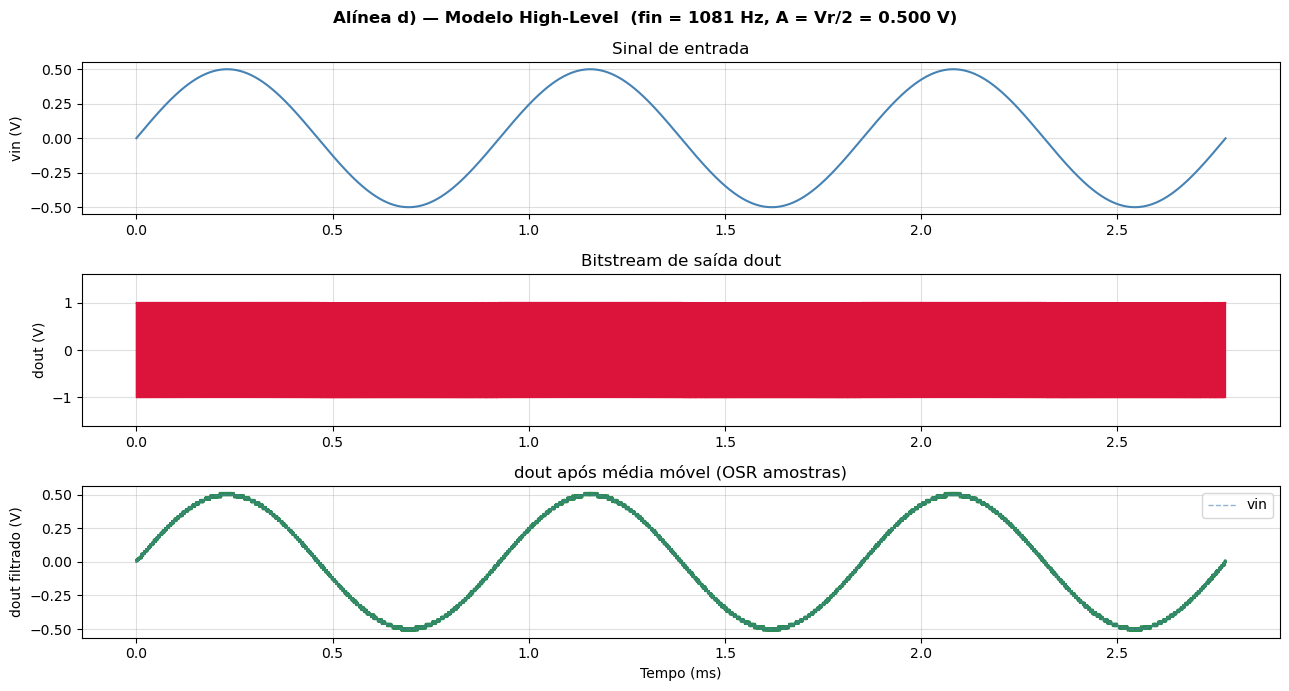

SNDR (sem ruído térmico) = 81.61 dB


In [225]:
vin_d  = (Vr/2) * np.sin(2*np.pi * k_bin * np.arange(np_sim) / np_sim)
dout_d = simulate_sdm(vin_d, Vr=Vr)

fig, axes = plt.subplots(3, 1, figsize=(13, 7))
fig.suptitle(f"Alínea d) — Modelo High-Level  (fin = {fin:.0f} Hz, A = Vr/2 = {Vr/2:.3f} V)",
             fontweight='bold')

n_show = int(3 / (fin/Fs))   # 3 períodos

axes[0].plot(t[:n_show]*1e3, vin_d[:n_show], color='steelblue', lw=1.5)
axes[0].set_ylabel("vin (V)"); axes[0].set_title("Sinal de entrada")
axes[0].grid(True, alpha=0.4)

axes[1].step(t[:n_show]*1e3, dout_d[:n_show], where='post', color='crimson', lw=1)
axes[1].set_ylabel("dout (V)"); axes[1].set_title("Bitstream de saída dout")
axes[1].set_ylim([-1.6*Vr, 1.6*Vr]); axes[1].grid(True, alpha=0.4)

# Média móvel simples para visualizar a reconstrução
from numpy.lib.stride_tricks import sliding_window_view
win_avg = int(OSR)
dout_avg = np.convolve(dout_d, np.ones(win_avg)/win_avg, mode='same')
axes[2].plot(t[:n_show]*1e3, dout_avg[:n_show], color='seagreen', lw=1.5)
axes[2].plot(t[:n_show]*1e3, vin_d[:n_show], color='steelblue', lw=1, ls='--', alpha=0.6, label='vin')
axes[2].set_ylabel("dout filtrado (V)"); axes[2].set_xlabel("Tempo (ms)")
axes[2].set_title("dout após média móvel (OSR amostras)")
axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

sndr_d, pwr_d = compute_sndr(dout_d, k_bin, np_sim, OSR)
print(f"SNDR (sem ruído térmico) = {sndr_d:.2f} dB")


---
## Alínea e) — Espectro de dout e SNDR em função do Ruído Térmico


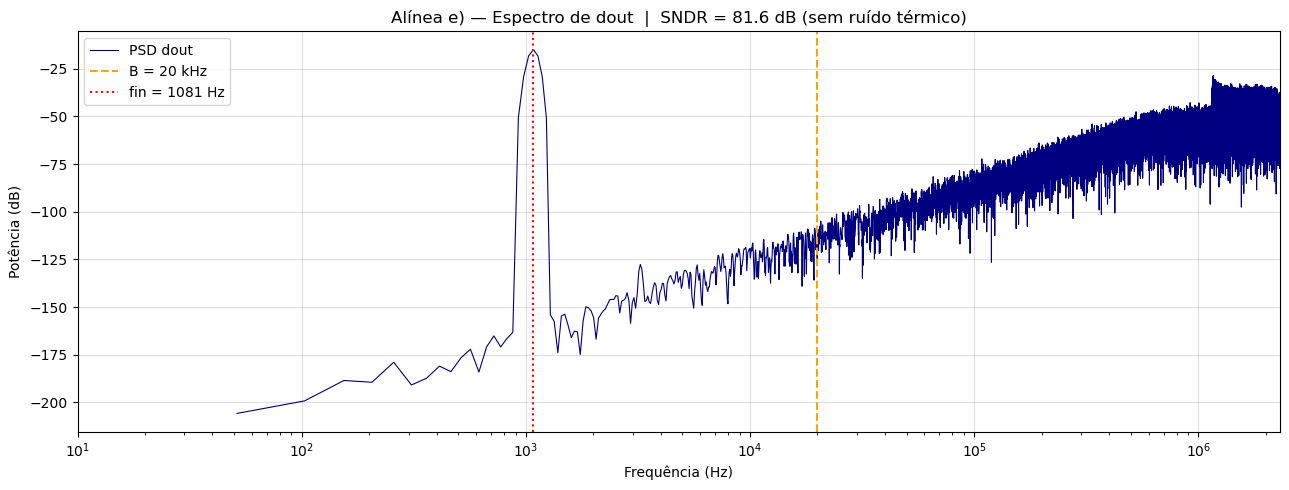

In [226]:
# ── Espectro de dout (sem ruído térmico) ──────────────────────────────────
ff = np.arange(np_sim) / np_sim   # eixo normalizado f/Fs

fig, ax = plt.subplots(figsize=(13, 5))
pwr_dB = 10*np.log10(pwr_d[:np_sim//2] + 1e-30)
ax.semilogx(ff[1:np_sim//2]*Fs, pwr_dB[1:], color='navy', lw=0.8, label='PSD dout')
ax.axvline(B,   color='orange', ls='--', lw=1.5, label=f'B = {B/1e3:.0f} kHz')
ax.axvline(fin, color='red',    ls=':',  lw=1.5, label=f'fin = {fin:.0f} Hz')
ax.set_xlabel("Frequência (Hz)"); ax.set_ylabel("Potência (dB)")
ax.set_title(f"Alínea e) — Espectro de dout  |  SNDR = {sndr_d:.1f} dB (sem ruído térmico)")
ax.set_xlim([10, Fs/2]); ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


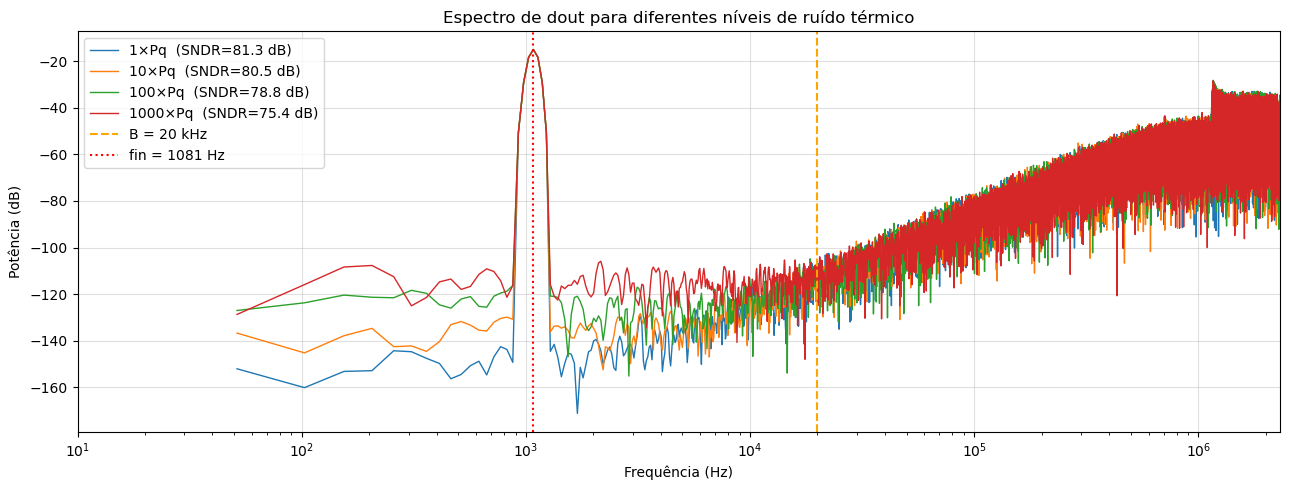

In [227]:
# Níveis de ruído a comparar    (ADICIONADO by GD)
noise_factors_plot = [1, 10, 100, 1000]

fig, ax = plt.subplots(figsize=(13,5))

for factor in noise_factors_plot:

    sigma_n = np.sqrt(factor * P_q)
    thermal = sigma_n * np.random.randn(np_sim)

    vin_n = (Vr/2) * np.sin(
        2*np.pi*k_bin*np.arange(np_sim)/np_sim
    ) + thermal

    d_n = simulate_sdm(vin_n, Vr=Vr)

    sndr_n, pwr_n = compute_sndr(
        d_n,
        k_bin,
        np_sim,
        OSR
    )

    pwr_dB = 10*np.log10(pwr_n[:np_sim//2] + 1e-30)

    ax.semilogx(
        ff[1:np_sim//2]*Fs,
        pwr_dB[1:],
        lw=1,
        label=f'{factor}×Pq  (SNDR={sndr_n:.1f} dB)'
    )

ax.axvline(
    B,
    color='orange',
    ls='--',
    lw=1.5,
    label=f'B = {B/1e3:.0f} kHz'
)

ax.axvline(
    fin,
    color='red',
    ls=':',
    lw=1.5,
    label=f'fin = {fin:.0f} Hz'
)

ax.set_xlabel("Frequência (Hz)")
ax.set_ylabel("Potência (dB)")
ax.set_title("Espectro de dout para diferentes níveis de ruído térmico")
ax.set_xlim([10, Fs/2])
ax.grid(True, alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

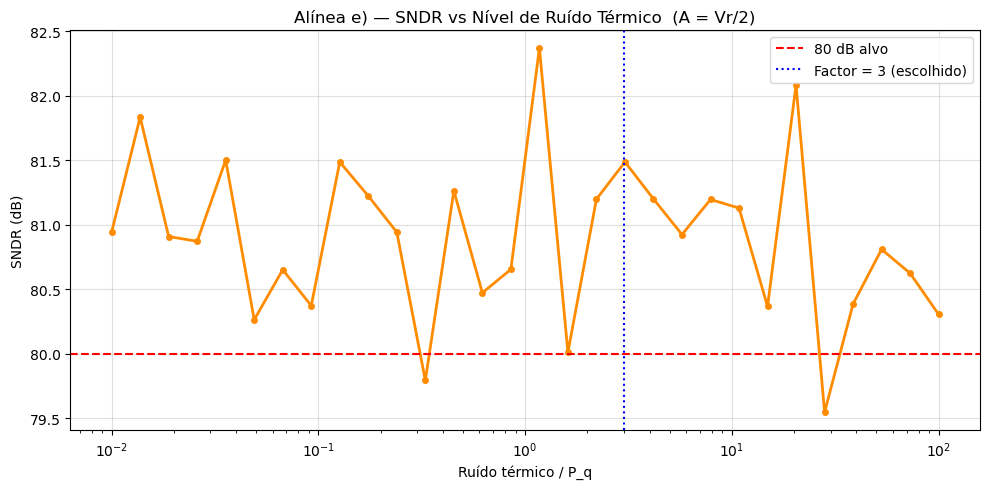

SNDR com ruído térmico = 3×P_q : 81.49 dB


In [228]:
# ── SNDR vs nível de ruído térmico ────────────────────────────────────────
noise_factors = np.logspace(-2, 2, 30)   # de 0.01×P_q a 100×P_q
sndr_vs_noise = []

for factor in noise_factors:
    sigma_n = np.sqrt(factor * P_q)
    thermal  = sigma_n * np.random.randn(np_sim)
    vin_n    = (Vr/2) * np.sin(2*np.pi * k_bin * np.arange(np_sim) / np_sim) + thermal
    d_n      = simulate_sdm(vin_n, Vr=Vr)
    s, _     = compute_sndr(d_n, k_bin, np_sim, OSR)
    sndr_vs_noise.append(s)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(noise_factors, sndr_vs_noise, 'o-', color='darkorange', lw=2, ms=4)
ax.axhline(80, color='red',  ls='--', lw=1.5, label='80 dB alvo')
ax.axvline(3,  color='blue', ls=':',  lw=1.5, label='Factor = 3 (escolhido)')
ax.set_xlabel("Ruído térmico / P_q"); ax.set_ylabel("SNDR (dB)")
ax.set_title("Alínea e) — SNDR vs Nível de Ruído Térmico  (A = Vr/2)")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

idx3 = np.argmin(np.abs(noise_factors - 3))
print(f"SNDR com ruído térmico = 3×P_q : {sndr_vs_noise[idx3]:.2f} dB")


---
## Alínea f) — SNDR vs Amplitude de Entrada | Gama Dinâmica (DR)

Ruído térmico fixo em $3 \times P_q$.  
DR calculado como a diferença em dB entre o ponto onde SNDR = SNDR_max − 3 dB (saturação)  
e o ponto onde SNDR = 0 dB (chão de ruído).


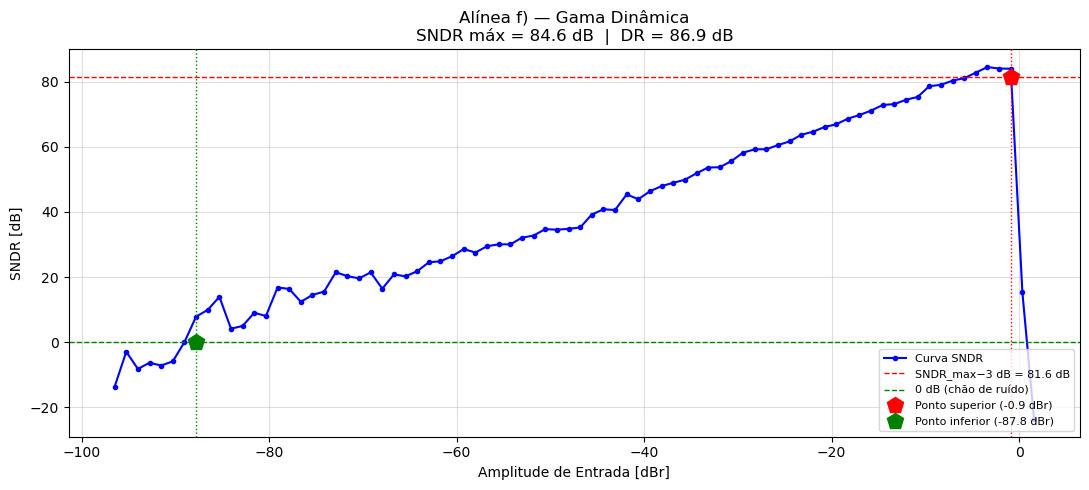

SNDR máximo   = 84.59 dB
Ponto superior= -0.90 dBr
Ponto inferior= -87.79 dBr
Dynamic Range = 86.89 dB


In [229]:
Amplitudes = np.logspace(np.log10(1.5e-5), np.log10(1.2*Vr), 80)
SNDR_amp   = np.zeros(len(Amplitudes))

for i, A in enumerate(Amplitudes):
    thermal = noise_sigma * np.random.randn(np_sim)
    vin_a   = A * np.sin(2*np.pi * k_bin * np.arange(np_sim) / np_sim) + thermal
    dout_a  = simulate_sdm(vin_a, Vr=Vr)
    SNDR_amp[i], _ = compute_sndr(dout_a, k_bin, np_sim, OSR)

Amp_dBr    = 20*np.log10(Amplitudes / Vr)
max_sndr   = np.max(SNDR_amp)
threshold  = max_sndr - 3

above_thr  = np.where(SNDR_amp >= threshold)[0]
above_zero = np.where(SNDR_amp >= 0)[0]

vin_upper  = Amp_dBr[above_thr[-1]]  if len(above_thr)  > 0 else Amp_dBr[-1]
vin_lower  = Amp_dBr[above_zero[0]]  if len(above_zero) > 0 else Amp_dBr[0]
DR_dB      = vin_upper - vin_lower

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(Amp_dBr, SNDR_amp, 'b-o', lw=1.5, ms=3, label='Curva SNDR')

ax.axhline(threshold,  color='red',   ls='--', lw=1, label=f'SNDR_max−3 dB = {threshold:.1f} dB')
ax.axhline(0,          color='green', ls='--', lw=1, label='0 dB (chão de ruído)')
ax.axvline(vin_upper,  color='red',   ls=':',  lw=1)
ax.axvline(vin_lower,  color='green', ls=':',  lw=1)
ax.plot(vin_upper, threshold, 'rp', ms=12, markerfacecolor='red',   label=f'Ponto superior ({vin_upper:.1f} dBr)')
ax.plot(vin_lower, 0,         'gp', ms=12, markerfacecolor='green', label=f'Ponto inferior ({vin_lower:.1f} dBr)')

ax.set_xlabel("Amplitude de Entrada [dBr]"); ax.set_ylabel("SNDR [dB]")
ax.set_title(f"Alínea f) — Gama Dinâmica\nSNDR máx = {max_sndr:.1f} dB  |  DR = {DR_dB:.1f} dB")
ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f"SNDR máximo   = {max_sndr:.2f} dB")
print(f"Ponto superior= {vin_upper:.2f} dBr")
print(f"Ponto inferior= {vin_lower:.2f} dBr")
print(f"Dynamic Range = {DR_dB:.2f} dB")


---
## Alínea g) — Ganho Finito dos Op-Amps (A = 40 dB)

Com ganho finito $A$, o integrador passa de pólo em $z=1$ (ideal) para pólo em $z = \beta < 1$:

$$\beta = 1 - \frac{1}{A}$$

Os dois integradores têm o mesmo valor de $A$ mas podem ter $\beta$ ligeiramente diferentes  
dependendo da topologia. Aqui usamos o mesmo $\beta$ para os dois integradores.


A = 10^(40/20) = 100.0
β = 1 - 1/A   = 0.99000


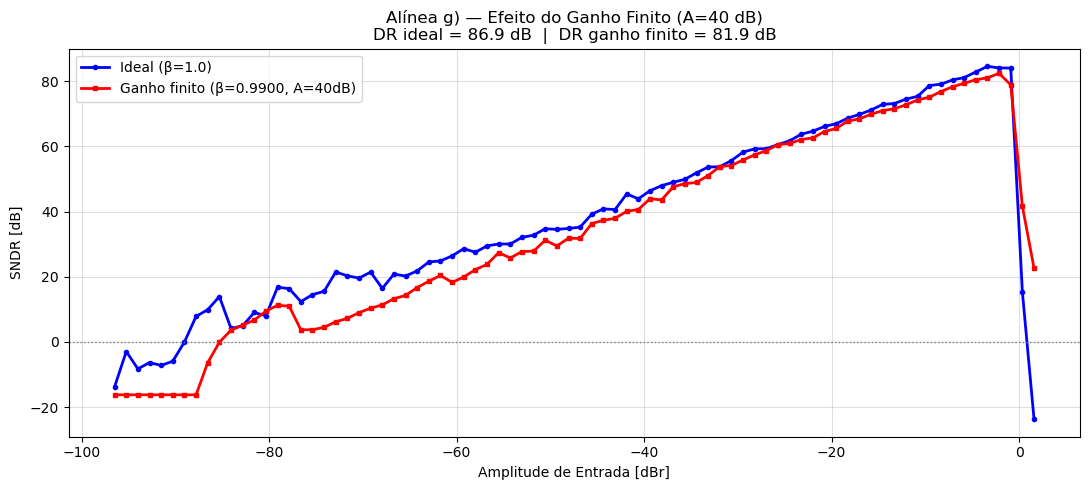

DR (ideal)       = 86.89 dB
DR (A=40dB)      = 81.93 dB
Degradação do DR = 4.97 dB


In [230]:
gain_dB  = 40
A_amp    = 10**(gain_dB / 20)    # ganho de tensão = 100
beta_val = 1.0 - 1.0 / A_amp    # β = 0.99

print(f"A = 10^(40/20) = {A_amp:.1f}")
print(f"β = 1 - 1/A   = {beta_val:.5f}")

# Repetir varrimento com integradores com leakage
SNDR_finite = np.zeros(len(Amplitudes))

for i, A in enumerate(Amplitudes):
    thermal    = noise_sigma * np.random.randn(np_sim)
    vin_g      = A * np.sin(2*np.pi * k_bin * np.arange(np_sim) / np_sim) + thermal
    dout_g     = simulate_sdm(vin_g, Vr=Vr, beta1=beta_val, beta2=beta_val)
    SNDR_finite[i], _ = compute_sndr(dout_g, k_bin, np_sim, OSR)

max_sndr_g = np.max(SNDR_finite)
above_thr_g  = np.where(SNDR_finite >= max_sndr_g - 3)[0]
above_zero_g = np.where(SNDR_finite >= 0)[0]
vin_upper_g  = Amp_dBr[above_thr_g[-1]]  if len(above_thr_g)  > 0 else Amp_dBr[-1]
vin_lower_g  = Amp_dBr[above_zero_g[0]]  if len(above_zero_g) > 0 else Amp_dBr[0]
DR_finite    = vin_upper_g - vin_lower_g

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(Amp_dBr, SNDR_amp,    'b-o',  lw=2, ms=3, label=f'Ideal (β=1.0)')
ax.plot(Amp_dBr, SNDR_finite, 'r-s',  lw=2, ms=3, label=f'Ganho finito (β={beta_val:.4f}, A=40dB)')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel("Amplitude de Entrada [dBr]"); ax.set_ylabel("SNDR [dB]")
ax.set_title(f"Alínea g) — Efeito do Ganho Finito (A=40 dB)\nDR ideal = {DR_dB:.1f} dB  |  DR ganho finito = {DR_finite:.1f} dB")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f"DR (ideal)       = {DR_dB:.2f} dB")
print(f"DR (A=40dB)      = {DR_finite:.2f} dB")
print(f"Degradação do DR = {DR_dB - DR_finite:.2f} dB")


---
## Alínea h) — Filtro Decimador Sinc³ (Média Móvel em Cascata)

### Princípio de funcionamento

O filtro Sinc³ (ou CIC de ordem 3) é implementado como **3 filtros de média móvel em cascata**,  
cada um com comprimento $M = D$ (factor de decimação = OSR arredondado):

$$H(z) = \left(\frac{1}{M}\sum_{k=0}^{M-1} z^{-k}\right)^3 = \left(\frac{1-z^{-M}}{M(1-z^{-1})}\right)^3$$

**Propriedades:**
- Zeros em $k \cdot F_s/M$ para $k = 1, 2, \ldots$ → suprime as imagens de aliasing
- Resposta de magnitude: $|H(f)| = \left|\frac{\sin(\pi f M / F_s)}{M \sin(\pi f / F_s)}\right|^3$
- Roll-off de 60 dB/decade → suficiente para NTF de 2ª ordem
- Extremamente simples: apenas somas, sem multiplicações
- Após filtragem, decimação por $M$ reduz $F_s$ para $F_{s2} = 2B$ (taxa de Nyquist)


In [231]:
D = round(OSR)   # factor de decimação = 116

# ── 3 médias móveis em cascata ────────────────────────────────────────────
h = np.ones(D) / D

thermal_h = noise_sigma * np.random.randn(np_sim)
vin_h     = (Vr/2) * np.sin(2*np.pi * k_bin * np.arange(np_sim) / np_sim) + thermal_h
dout_h    = simulate_sdm(vin_h, Vr=Vr)

dout_s1 = np.convolve(dout_h, h, mode='full')[:np_sim]
dout_s2 = np.convolve(dout_s1, h, mode='full')[:np_sim]
dout_s3 = np.convolve(dout_s2, h, mode='full')[:np_sim]

# SNDR antes da decimação (na taxa original Fs)
sndr_s3, pwr_s3 = compute_sndr(dout_h, k_bin, np_sim, OSR)

# ── Decimação por D ───────────────────────────────────────────────────────
dout_dec  = dout_s3[::D]
np_dec    = len(dout_dec)
Fs2       = Fs / D                    # nova taxa = 40 kHz
k_bin_dec = round(np_dec * (fin / Fs2))   # bin do sinal após decimação

sndr_dec, pwr_dec = compute_sndr(dout_dec, k_bin_dec, np_dec, OSR=1/(2*(B/Fs2)))

print(f"Factor de decimação D = {D}")
print(f"Fs2 (após decimação)  = {Fs2/1e3:.1f} kHz  (= 2B, taxa de Nyquist)")
print(f"np após decimação     = {np_dec}")
print(f"SNDR antes decimação  = {sndr_s3:.2f} dB")
print(f"SNDR após decimação   = {sndr_dec:.2f} dB")


Factor de decimação D = 116
Fs2 (após decimação)  = 39.9 kHz  (= 2B, taxa de Nyquist)
np após decimação     = 776
SNDR antes decimação  = 81.34 dB
SNDR após decimação   = 86.17 dB


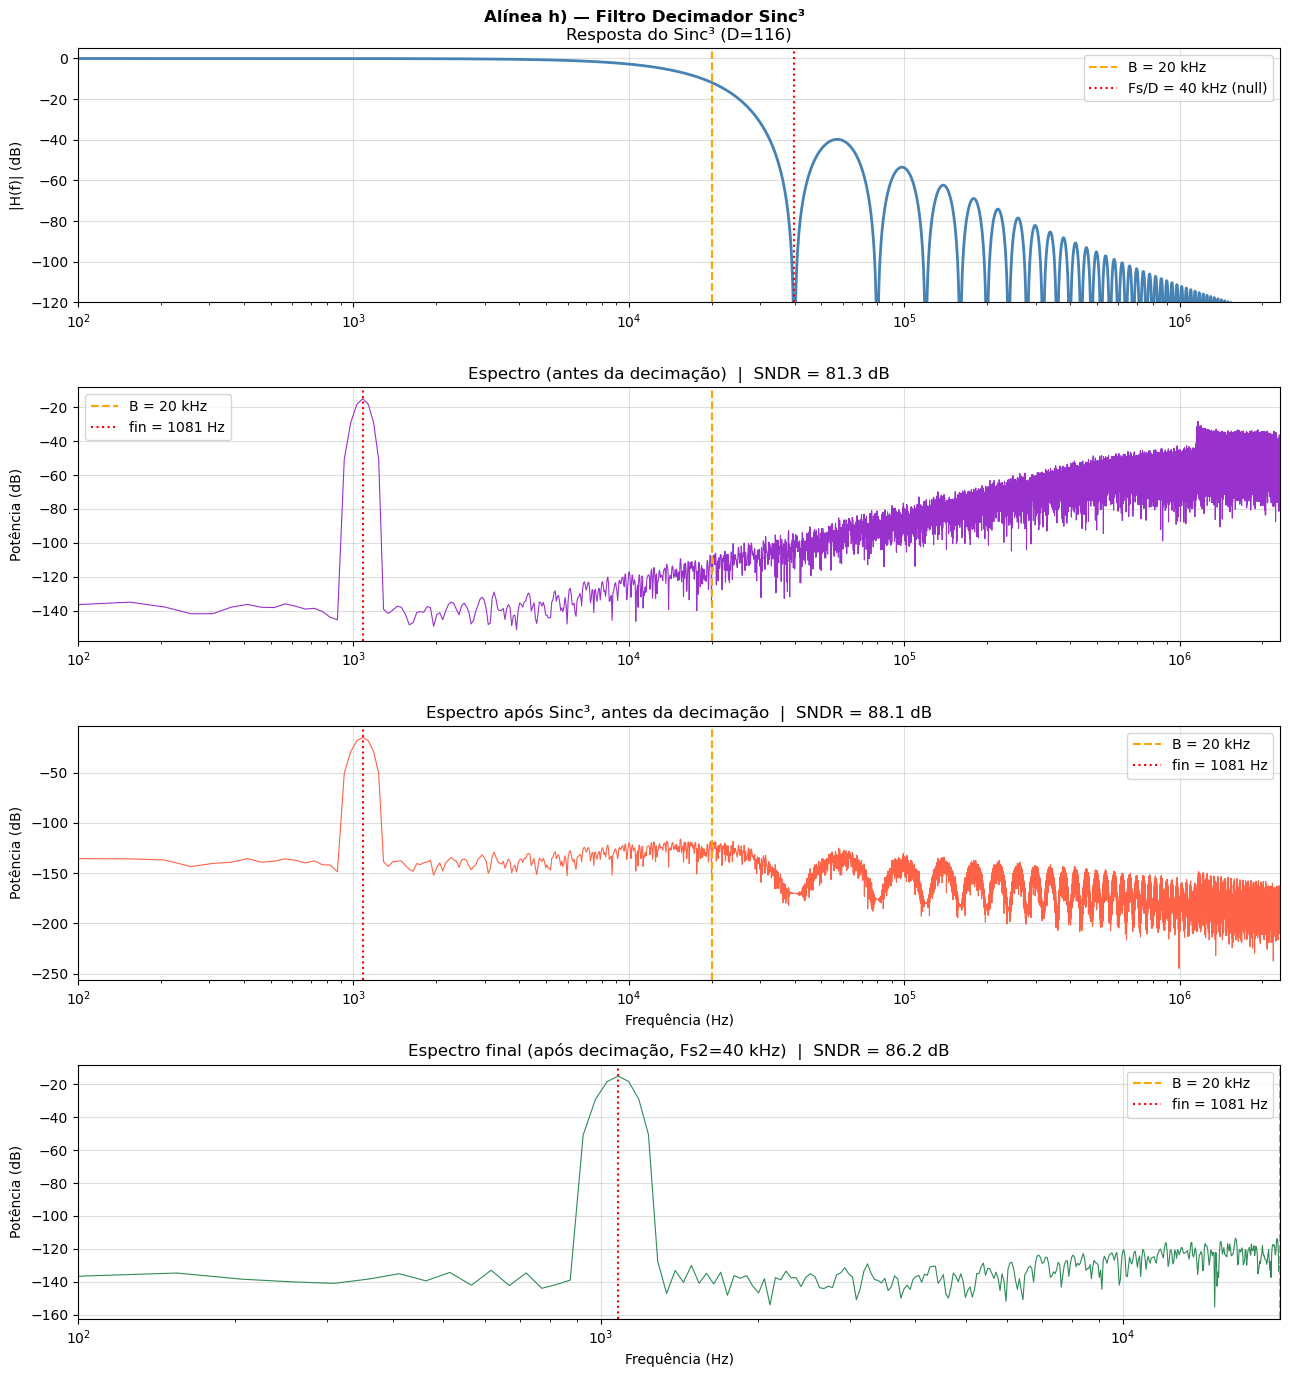

In [232]:
# Espectro de dout_s3 (após filtro, antes da decimação)
sndr_s3_filt, pwr_s3_filt = compute_sndr(dout_s3, k_bin, np_sim, OSR)


# ── Resposta em frequência do filtro Sinc³ ────────────────────────────────
f_hz   = np.linspace(1, Fs/2, 10000)
arg    = np.pi * f_hz * D / Fs
H_sinc = (np.abs(np.sin(arg)) / (D * np.abs(np.sin(np.pi * f_hz / Fs)) + 1e-15))**3
H_sinc_dB = 20*np.log10(H_sinc / H_sinc[0] + 1e-15)

# ── Espectros ─────────────────────────────────────────────────────────────
ff_hz    = np.arange(np_sim) / np_sim * Fs
ff_dec   = np.arange(np_dec) / np_dec * Fs2

fig, axes = plt.subplots(4, 1, figsize=(13, 14))
fig.suptitle("Alínea h) — Filtro Decimador Sinc³", fontweight='bold')

# Resposta do filtro
axes[0].semilogx(f_hz, H_sinc_dB, color='steelblue', lw=2)
axes[0].axvline(B,    color='orange', ls='--', lw=1.5, label=f'B = {B/1e3:.0f} kHz')
axes[0].axvline(Fs/D, color='red',   ls=':',  lw=1.5, label=f'Fs/D = {Fs/D/1e3:.0f} kHz (null)')
axes[0].set_ylim([-120, 5]); axes[0].set_xlim([100, Fs/2])
axes[0].set_ylabel("|H(f)| (dB)"); axes[0].set_title(f"Resposta do Sinc³ (D={D})")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Espectro antes da decimação
pwr_s3_dB = 10*np.log10(pwr_s3[:np_sim//2] + 1e-30)
axes[1].semilogx(ff_hz[1:np_sim//2], pwr_s3_dB[1:], color='darkorchid', lw=0.8)
axes[1].axvline(B,   color='orange', ls='--', lw=1.5, label=f'B = {B/1e3:.0f} kHz')
axes[1].axvline(fin, color='red',    ls=':',  lw=1.5, label=f'fin = {fin:.0f} Hz')
axes[1].set_xlim([100, Fs/2])
axes[1].set_ylabel("Potência (dB)"); axes[1].set_title(f"Espectro (antes da decimação)  |  SNDR = {sndr_s3:.1f} dB")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Espectro após filtro, antes da decimação
pwr_s3_filt_dB = 10*np.log10(pwr_s3_filt[:np_sim//2] + 1e-30)
axes[2].semilogx(ff_hz[1:np_sim//2], pwr_s3_filt_dB[1:], color='tomato', lw=0.8)
axes[2].axvline(B,   color='orange', ls='--', lw=1.5, label=f'B = {B/1e3:.0f} kHz')
axes[2].axvline(fin, color='red',    ls=':',  lw=1.5, label=f'fin = {fin:.0f} Hz')
axes[2].set_xlim([100, Fs/2])
axes[2].set_xlabel("Frequência (Hz)")
axes[2].set_ylabel("Potência (dB)")
axes[2].set_title(f"Espectro após Sinc³, antes da decimação  |  SNDR = {sndr_s3_filt:.1f} dB")
axes[2].legend()
axes[2].grid(True, alpha=0.4)

# Espectro após decimação
pwr_dec_dB = 10*np.log10(pwr_dec[:np_dec//2] + 1e-30)
axes[3].semilogx(ff_dec[1:np_dec//2], pwr_dec_dB[1:], color='seagreen', lw=0.8)
axes[3].axvline(B,   color='orange', ls='--', lw=1.5, label=f'B = {B/1e3:.0f} kHz')
axes[3].axvline(fin, color='red',    ls=':',  lw=1.5, label=f'fin = {fin:.0f} Hz')
axes[3].set_xlim([100, Fs2/2])
axes[3].set_xlabel("Frequência (Hz)"); axes[3].set_ylabel("Potência (dB)")
axes[3].set_title(f"Espectro final (após decimação, Fs2={Fs2/1e3:.0f} kHz)  |  SNDR = {sndr_dec:.1f} dB")
axes[3].legend(); axes[3].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


---
## Resumo dos Resultados


In [233]:
print("=" * 55)
print("  RESUMO — Sigma Delta Modulator (Alíneas a-h)")
print("=" * 55)
print(f"  STF(z)            = z^{{-2}}")
print(f"  NTF(z)            = (1 - z^{{-1}})^2")
print(f"  Vr                = √2 = {Vr:.4f} V  (1 Vrms)")
print(f"  OSR               = {OSR}")
print(f"  Fs                = {Fs/1e3:.2f} kHz")
print(f"  P_q               = {P_q:.4e} V²  ({10*np.log10(P_q):.1f} dBV²)")
print(f"  fin               = {fin:.2f} Hz")
print(f"  SNDR (sem ruído)  = {sndr_d:.1f} dB")
print(f"  SNDR (3×P_q)      = {sndr_vs_noise[idx3]:.1f} dB")
print(f"  SNDR máximo (f)   = {max_sndr:.1f} dB")
print(f"  DR (ideal)        = {DR_dB:.1f} dB")
print(f"  β (A=40 dB)       = {beta_val:.5f}")
print(f"  DR (A=40 dB)      = {DR_finite:.1f} dB")
print(f"  D (decimação)     = {D}")
print(f"  Fs2               = {Fs2/1e3:.1f} kHz")
print(f"  SNDR após Sinc³   = {sndr_dec:.1f} dB")
print("=" * 55)


  RESUMO — Sigma Delta Modulator (Alíneas a-h)
  STF(z)            = z^{-2}
  NTF(z)            = (1 - z^{-1})^2
  Vr                = √2 = 1.0000 V  (1 Vrms)
  OSR               = 115.8
  Fs                = 4632.00 kHz
  P_q               = 3.1186e-10 V²  (-95.1 dBV²)
  fin               = 1080.80 Hz
  SNDR (sem ruído)  = 81.6 dB
  SNDR (3×P_q)      = 81.5 dB
  SNDR máximo (f)   = 84.6 dB
  DR (ideal)        = 86.9 dB
  β (A=40 dB)       = 0.99000
  DR (A=40 dB)      = 81.9 dB
  D (decimação)     = 116
  Fs2               = 39.9 kHz
  SNDR após Sinc³   = 86.2 dB


In [234]:
#Alínea K

data = np.loadtxt("SC_second_order_v1.txt", skiprows=1)

